In [1]:
import pandas as pd
import matplotlib.pyplot as plt # visualizing data
import seaborn as sns

In [67]:
df = pd.read_csv("income_evaluation.csv")

In [68]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
df.shape

(32561, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              32561 non-null  int64 
 1    workclass       32561 non-null  object
 2    fnlwgt          32561 non-null  int64 
 3    education       32561 non-null  object
 4    education-num   32561 non-null  int64 
 5    marital-status  32561 non-null  object
 6    occupation      32561 non-null  object
 7    relationship    32561 non-null  object
 8    race            32561 non-null  object
 9    sex             32561 non-null  object
 10   capital-gain    32561 non-null  int64 
 11   capital-loss    32561 non-null  int64 
 12   hours-per-week  32561 non-null  int64 
 13   native-country  32561 non-null  object
 14   income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [69]:
df.columns

Index(['age', ' workclass', ' fnlwgt', ' education', ' education-num',
       ' marital-status', ' occupation', ' relationship', ' race', ' sex',
       ' capital-gain', ' capital-loss', ' hours-per-week', ' native-country',
       ' income'],
      dtype='object')

In [75]:
df.duplicated().sum()

0

In [74]:
df.drop_duplicates(inplace=True)

In [72]:
df.isnull().sum()

fnlwgt            0
workclass         0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [ ]:
# To find the row with the maximum age

df.iloc[df["age"].idxmax()]

age                            90
 workclass                Private
 fnlwgt                     51744
 education                HS-grad
 education-num                  9
 marital-status     Never-married
 occupation         Other-service
 relationship       Not-in-family
 race                       Black
 sex                         Male
 capital-gain                   0
 capital-loss                2206
 hours-per-week                40
 native-country     United-States
 income                     <=50K
Name: 222, dtype: object

In [70]:
df = df[[" fnlwgt", " workclass", " education", " education-num", " marital-status", " occupation", " relationship", " race", " sex", " capital-gain", " capital-loss", " hours-per-week", " native-country", " income"]]
df.columns = [["fnlwgt", "workclass", "education", "education-num", "marital-status", "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"]]

In [71]:
df.head()

,fnlwgt,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,77516,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,83311,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,215646,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,234721,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,338409,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [76]:
# To find the five least represented workclass categories

count_workclass = df["workclass"].value_counts().sort_values(ascending=True).head(5)
count_workclass

(workclass,)
Never-worked       7
Without-pay       14
Federal-gov      960
Self-emp-inc    1116
State-gov       1298
Name: count, dtype: int64

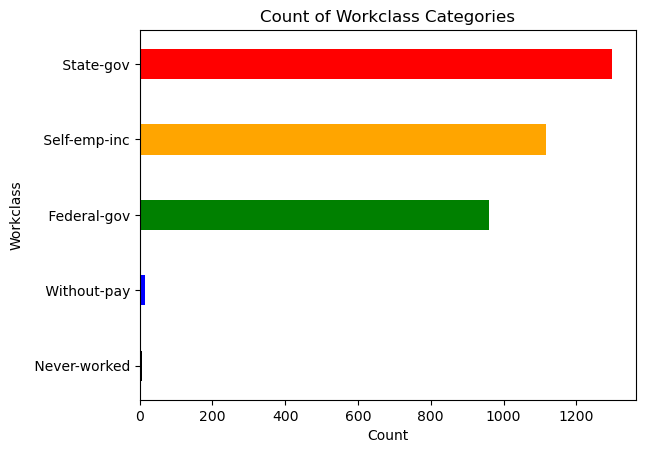

In [39]:
# Visualizing the workclass counts

count_workclass.plot(kind='barh', color=['black', 'blue', 'green', 'orange', 'red'], width=0.4)
plt.xlabel("Count")
plt.ylabel("Workclass")
plt.title("Count of Workclass Categories")
plt.show()

In [77]:
value_count_income = df["income"].value_counts().sort_values(ascending=True)
value_count_income

(income,)
>50K          7835
<=50K        24659
Name: count, dtype: int64

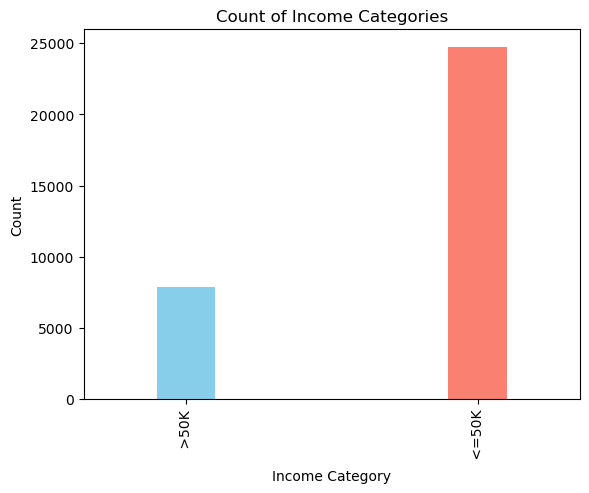

In [29]:
# Visualizing the income counts

value_count_income.plot(kind='bar', color=['skyblue', 'salmon'], width=0.2)
plt.xlabel("Income Category")
plt.ylabel("Count")
plt.title("Count of Income Categories")
plt.show()

In [78]:
# To find the top 10 education levels

education_value_count = df["education"].value_counts().sort_values(ascending=True).tail(10)
education_value_count

(education,)
Prof-school       575
7th-8th           645
10th              933
Assoc-acdm       1067
11th             1175
Assoc-voc        1381
Masters          1722
Bachelors        5348
Some-college     7269
HS-grad         10474
Name: count, dtype: int64

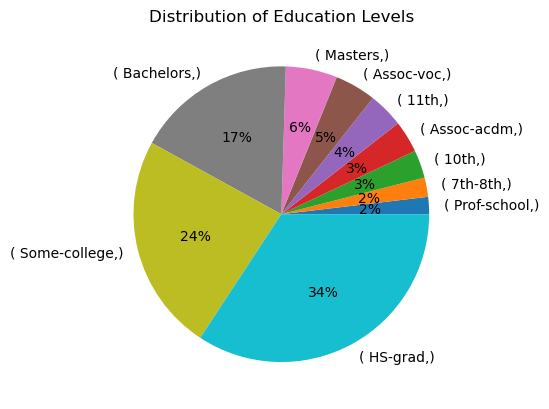

In [79]:
# Visualizing the education level distribution

education_value_count.plot(kind="pie", autopct='%1.0f%%')
plt.title("Distribution of Education Levels")
plt.ylabel("")
plt.show()

In [80]:
sexlabels = df["sex"].value_counts()
sexlabels

(sex,)
Male      21743
Female    10751
Name: count, dtype: int64

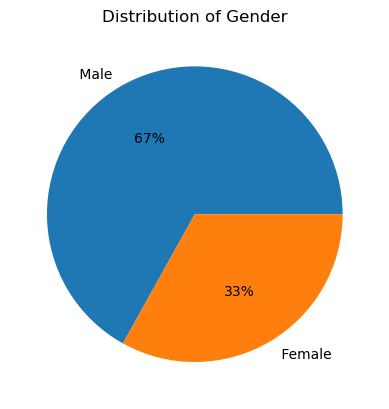

In [50]:
sexlabels.plot(kind='pie', autopct='%1.0f%%')
plt.title("Distribution of Gender")
plt.ylabel("")
plt.show()

In [81]:
# To find the top 6 marital status categories

maritalstatus = df["marital-status"].value_counts().head(6)
maritalstatus

(marital-status,)    
Married-civ-spouse       14955
Never-married            10641
Divorced                  4440
Separated                 1025
Widowed                    993
Married-spouse-absent      417
Name: count, dtype: int64

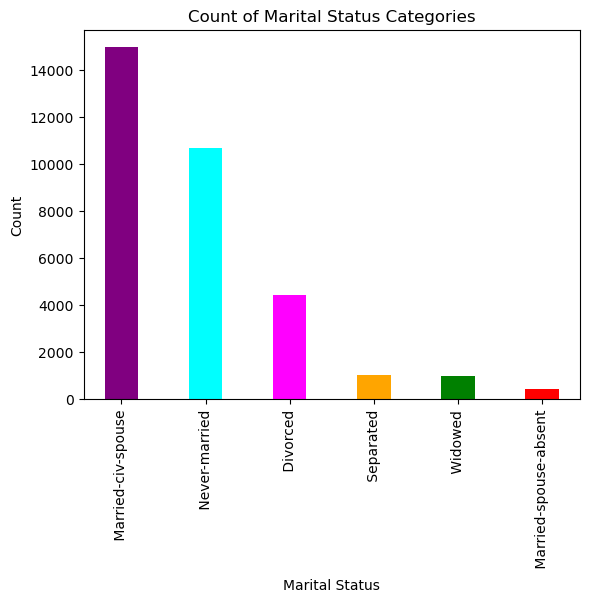

In [ ]:
# Visualizing the marital status distribution in a bar chart

maritalstatus.plot(kind='bar', color=['purple', 'cyan', 'magenta', 'orange', 'green', 'red', 'blue'], width=0.4)
plt.xlabel("Marital Status")
plt.ylabel("Count")
plt.title("Count of Marital Status Categories")
plt.show()

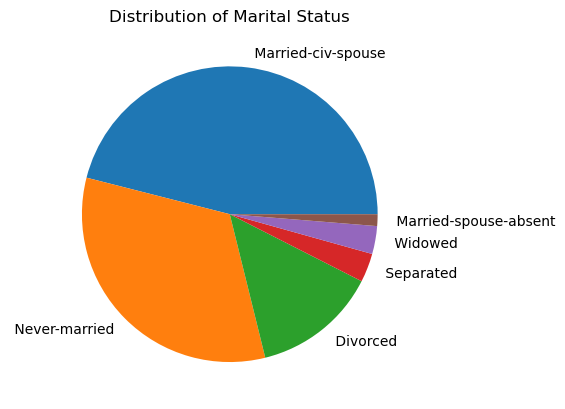

In [ ]:
# Visualizing the marital status distribution in a pie chart

maritalstatus.plot(kind="pie")
plt.title("Distribution of Marital Status")
plt.ylabel("")
plt.show()